I am building a **sentiment classification system** that predicts whether a restaurant review expresses positive or negative sentiment.

Restaurant review platforms contain massive volumes of textual feedback. Automatically classifying sentiment helps:

* businesses monitor customer satisfaction

* identify recurring complaints

* analyze trends in customer experience

In [3]:
import torch

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print(device)


cuda


In [4]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("farukalam/yelp-restaurant-reviews")

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'yelp-restaurant-reviews' dataset.
Path to dataset files: /kaggle/input/yelp-restaurant-reviews


In [5]:
import pandas as pd
df = pd.read_csv('/kaggle/input/yelp-restaurant-reviews/Yelp Restaurant Reviews.csv')
df.info()
df.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 19896 entries, 0 to 19895
Data columns (total 4 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   Yelp URL     19896 non-null  object
 1   Rating       19896 non-null  int64 
 2   Date         19896 non-null  object
 3   Review Text  19896 non-null  object
dtypes: int64(1), object(3)
memory usage: 621.9+ KB


,Yelp URL,Rating,Date,Review Text
0,https://www.yelp.com/biz/sidney-dairy-barn-sidney,5,1/22/2022,All I can say is they have very good ice cream...
1,https://www.yelp.com/biz/sidney-dairy-barn-sidney,4,6/26/2022,Nice little local place for ice cream.My favor...
2,https://www.yelp.com/biz/sidney-dairy-barn-sidney,5,8/7/2021,A delicious treat on a hot day! Staff was very...
3,https://www.yelp.com/biz/sidney-dairy-barn-sidney,4,7/28/2016,This was great service and a fun crew! I got t...
4,https://www.yelp.com/biz/sidney-dairy-barn-sidney,5,6/23/2015,This is one of my favorite places to get ice c...


# EDA(Exploratory Data Analysis)
Need to understand the dataset:
* Distribution of ratings.
* class balance(positive and negative).
* length of the reviews.
* common words and phrases.


1. Check for the missing values

In [6]:
# check for missing values
print(df.isnull().sum())
# renaming the columns for easier access
df = df.rename(columns={
    "Review Text": "review",
    "Rating": "rating"
})


Yelp URL       0
Rating         0
Date           0
Review Text    0
dtype: int64


The dataset contains 19,896 entries with no missing values. Key columns like 'Review Text' and 'Rating' were renamed for easier access.

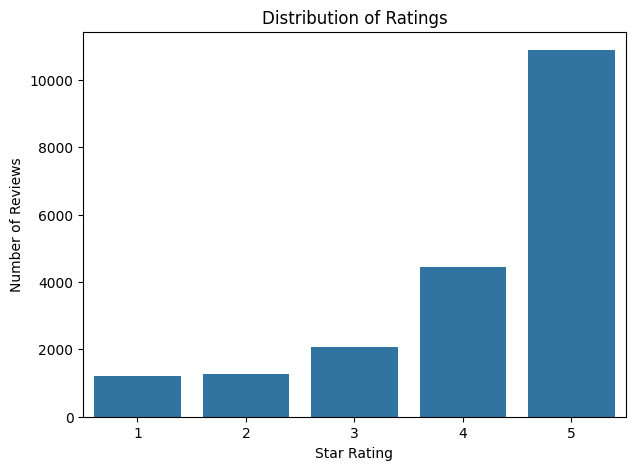

In [7]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(7,5))

sns.countplot(x=df["rating"])

plt.title("Distribution of Ratings")
plt.xlabel("Star Rating")
plt.ylabel("Number of Reviews")

plt.show()


A countplot showed the distribution of Yelp star ratings, indicating a higher frequency of positive reviews (4 and 5 stars).

In [8]:
df["review_length"] = df["review"].apply(len)
print(df["review_length"].describe())


count    19896.000000
mean       493.933353
std        433.011039
min          7.000000
25%        208.000000
50%        365.000000
75%        636.000000
max       5990.000000
Name: review_length, dtype: float64


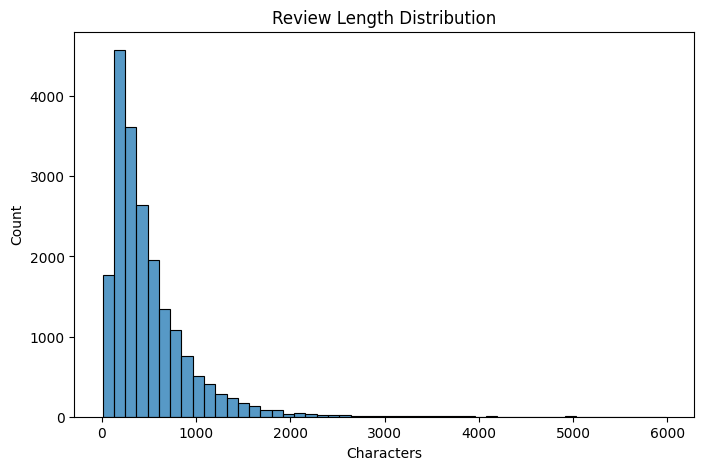

In [9]:
plt.figure(figsize=(8,5))

sns.histplot(df["review_length"], bins=50)

plt.title("Review Length Distribution")
plt.xlabel("Characters")
plt.ylabel("Count")

plt.show()


The average review length is around 494 characters, with reviews ranging from a minimum of 7 characters to a maximum of 5990 characters. A histogram further illustrated this distribution.

In [10]:
def label_sentiment(rating):
    if rating >= 4:
        return "positive"
    elif rating <= 2:
        return "negative"
    else:
        return "neutral"

df["sentiment"] = df["rating"].apply(label_sentiment)


To convert this from a multi-class classification to a binary class classification we label the rating< 3 as negative and rating> 3 as positive.We remove the rating=3 for now(neutral).

sentiment
positive    15330
negative     2497
neutral      2069
Name: count, dtype: int64


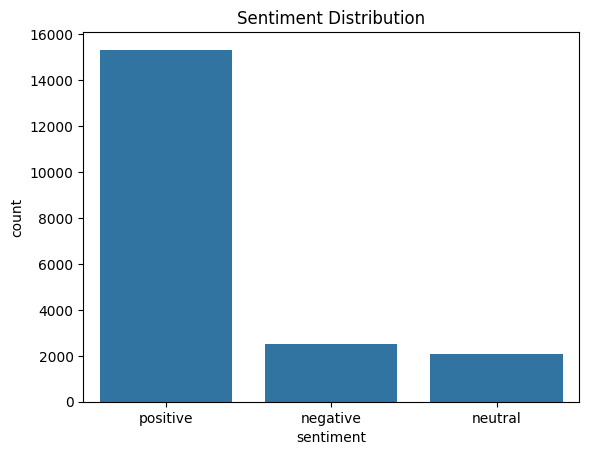

In [11]:
# to check the sentiment distribution
print(df["sentiment"].value_counts())
sns.countplot(x=df["sentiment"])
plt.title("Sentiment Distribution")
plt.show()


In [12]:
df = df[df["sentiment"] != "neutral"]
print(df["sentiment"].value_counts())


sentiment
positive    15330
negative     2497
Name: count, dtype: int64


Reviews were categorized into 'positive' (rating >= 4), 'negative' (rating <= 2), and 'neutral' (rating = 3). The initial sentiment distribution showed a strong dominance of positive reviews. Subsequently, 'neutral' reviews were removed to focus on distinct positive and negative sentiments.

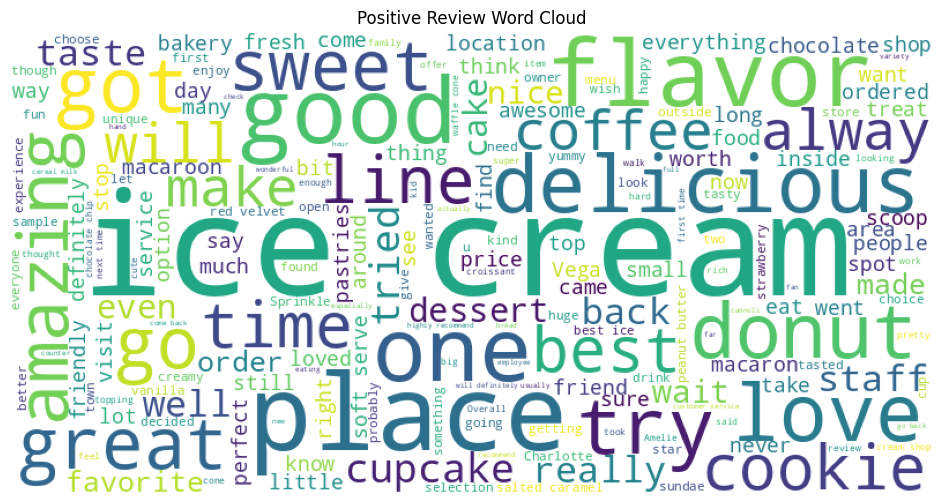

In [13]:
from wordcloud import WordCloud

positive_reviews = " ".join(df[df["sentiment"]=="positive"]["review"])

wordcloud = WordCloud(width=800,height=400,background_color="white").generate(positive_reviews)

plt.figure(figsize=(12,6))
plt.imshow(wordcloud)
plt.axis("off")
plt.title("Positive Review Word Cloud")

plt.show()


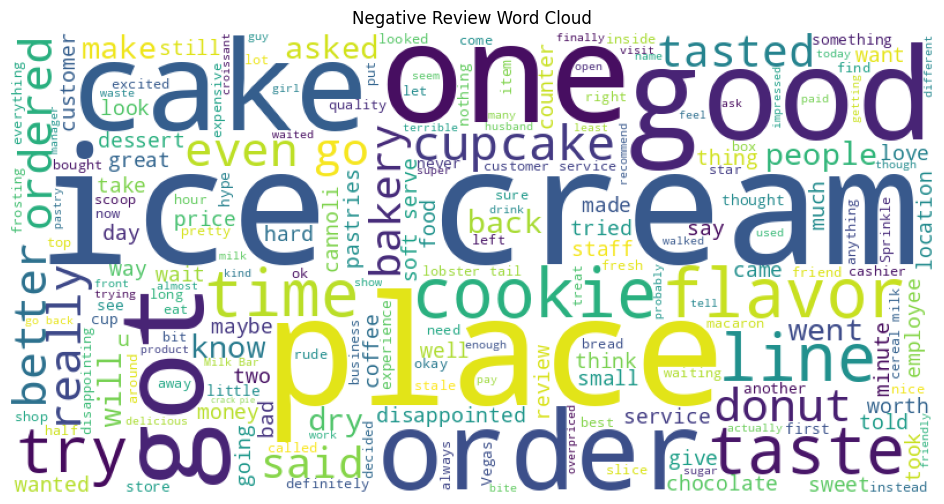

In [14]:
negative_reviews = " ".join(df[df["sentiment"]=="negative"]["review"])

wordcloud = WordCloud(width=800,height=400,background_color="white").generate(negative_reviews)

plt.figure(figsize=(12,6))
plt.imshow(wordcloud)
plt.axis("off")
plt.title("Negative Review Word Cloud")

plt.show()


Word clouds were generated for both positive and negative reviews, offering a visual representation of the most frequent words in each sentiment category. This can provide initial insights into common themes and topics associated with positive and negative customer experiences.

In [15]:
df.head()

,Yelp URL,rating,Date,review,review_length,sentiment
0,https://www.yelp.com/biz/sidney-dairy-barn-sidney,5,1/22/2022,All I can say is they have very good ice cream...,123,positive
1,https://www.yelp.com/biz/sidney-dairy-barn-sidney,4,6/26/2022,Nice little local place for ice cream.My favor...,290,positive
2,https://www.yelp.com/biz/sidney-dairy-barn-sidney,5,8/7/2021,A delicious treat on a hot day! Staff was very...,131,positive
3,https://www.yelp.com/biz/sidney-dairy-barn-sidney,4,7/28/2016,This was great service and a fun crew! I got t...,374,positive
4,https://www.yelp.com/biz/sidney-dairy-barn-sidney,5,6/23/2015,This is one of my favorite places to get ice c...,848,positive


Spliting the datset into train & test.Using **stratify** to ensure the class proportion stays the same within the ttest and train splits.

In [16]:
from sklearn.model_selection import train_test_split

X = df["review"]
y = df["sentiment"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)


## NLTK Text Preprocessing

* nltk(natural language toolkit):to remove the stop words and to get the logical shortened words.
* re(regular expressions):used for pattern matching (here it is used for removing numbers)
* PorterStemmer:algorithm to find the root word

Downloads the list of common words(a,an,the,is,are)(to have a reference file)

In [17]:
import nltk
nltk.download("stopwords")


[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


True

In [18]:
import re
import string

from nltk.corpus import stopwords
from nltk.stem import PorterStemmer


In [19]:
stop_words = set(stopwords.words("english"))
stemmer = PorterStemmer()


* Convert the text to lower case(so that Hello and hello do not become differnt words).
* Remove the digits as they are not really helpful is determining the sentiment.
* Remove all the punctuations(it is noise and does not add any semantic meaning to the basic models)
* split the test into words
* Stemming is done to chop the word to its root and also to check if it is a stop word.(jumping,jumps,jumped->jump)

Example:
"The 2 runners were sprinting fast"
becomes
* the 2 runners were sprinting fast
* the runners were sprinting fast
* ['the','runners','were','sprinting','fast']
* ['runners','sprinting','fast']
* ['runner','sprint','fast']

final:"runner sprint fast"

In [20]:
def preprocess_nltk(text):

    text = text.lower()

    text = re.sub(r'\d+', '', text)

    text = text.translate(str.maketrans('', '', string.punctuation))

    words = text.split()

    words = [stemmer.stem(word) for word in words if word not in stop_words]

    return " ".join(words)


We split the dataset and then do preprocessing to prevent **data leakage**.
(Info doesnt leak into the trainig data)

In [21]:
X_train_nltk = X_train.apply(preprocess_nltk)
X_test_nltk = X_test.apply(preprocess_nltk)


## SPACY Text Preprocessing

Load the pre-trained model for english.

In [22]:
import spacy

nlp = spacy.load("en_core_web_sm")


* Runs the text throught the full pipeline.
* Lemmatization:finds the dictionary root of the word.(Better->good , was->be)
* checks a built-in stopword list.
* spacy knows what punctuations are no need for re.(ensures that punctuations are not passed through the pipeline).
* checks for tabs,newlines,or extra spaces(does the formatting).


In [23]:
def preprocess_spacy(text):

    doc = nlp(text.lower())

    tokens = [
        token.lemma_
        for token in doc
        if not token.is_stop
        and not token.is_punct
        and not token.is_space
    ]

    return " ".join(tokens)


In [24]:
X_train_spacy = X_train.apply(preprocess_spacy)
X_test_spacy = X_test.apply(preprocess_spacy)


Differences between NLTK Vs spaCy:

"The feet were running better"
* NLTK-"feet run better"
* spaCy-"foot run good"



TF-IDF(Term Frequency-Inverse Document Frequency)
instead of bag-of-words(counting the occurance of a word)
* TF (Term Frequency): How often does the word appear in this document? (More is better).
* IDF (Inverse Document Frequency): How rare is this word across the entire dataset? (Rare is better).

* uses n-gram-(1,2)single and pairs
limits size of vocabulary by max_features(only 10000 important words)
* vectorizer.fit_transform(X_train_nltk)->learns vocab->calculates the IDF scores,converts the text to numbers(vectors).
only do this on train not on test(we ensures the model learns on the features using the training data but not on test data->data leakage).
* Output->table(rows-documents,columns-10000unique words).




In [25]:
from sklearn.feature_extraction.text import TfidfVectorizer

vectorizer = TfidfVectorizer(
    ngram_range=(1,2),
    max_features=10000
)


X_train_nltk_tfidf = vectorizer.fit_transform(X_train_nltk)
X_test_nltk_tfidf = vectorizer.transform(X_test_nltk)

vectorizer_spacy = TfidfVectorizer(
    ngram_range=(1,2),
    max_features=10000
)

X_train_spacy_tfidf = vectorizer_spacy.fit_transform(X_train_spacy)
X_test_spacy_tfidf = vectorizer_spacy.transform(X_test_spacy)


In [26]:
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC

from sklearn.model_selection import GridSearchCV
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score


* GridSearchCV:Instead of you manually trying different settings, it runs multiple experiments to find which one works best.Prioritize F1-score(accuracy cannot be trusted since there is a class imbalance).
* We use cross-validation=5

In [27]:
log_reg = LogisticRegression(max_iter=1000)

param_grid = {
    "C": [0.01, 0.1, 1, 10]
}

grid_log_nltk = GridSearchCV(
    log_reg,
    param_grid,
    cv=5,
    scoring="f1_macro",
    n_jobs=-1
)

grid_log_nltk.fit(X_train_nltk_tfidf, y_train)
best_log_nltk = grid_log_nltk.best_estimator_
y_pred_log_nltk = best_log_nltk.predict(X_test_nltk_tfidf)
print("NLTK + Logistic Regression")

print("Accuracy:", accuracy_score(y_test, y_pred_log_nltk))

print(classification_report(y_test, y_pred_log_nltk))

print(confusion_matrix(y_test, y_pred_log_nltk))


NLTK + Logistic Regression
Accuracy: 0.9531688166012339
              precision    recall  f1-score   support

    negative       0.91      0.74      0.81       499
    positive       0.96      0.99      0.97      3067

    accuracy                           0.95      3566
   macro avg       0.94      0.86      0.89      3566
weighted avg       0.95      0.95      0.95      3566

[[ 367  132]
 [  35 3032]]


* c->regularization parameters.
* while logistic regression is good for understanding the influence of a sepcific word,SVM is more effective in high dimentional space.

In [28]:
svm_model = LinearSVC()

param_grid = {
    "C": [0.01, 0.1, 1, 10]
}

grid_svm_nltk = GridSearchCV(
    svm_model,
    param_grid,
    cv=5,
    scoring="f1_macro",
    n_jobs=-1
)

grid_svm_nltk.fit(X_train_nltk_tfidf, y_train)
best_svm_nltk = grid_svm_nltk.best_estimator_
y_pred_svm_nltk = best_svm_nltk.predict(X_test_nltk_tfidf)
print("NLTK + SVM")

print("Accuracy:", accuracy_score(y_test, y_pred_svm_nltk))

print(classification_report(y_test, y_pred_svm_nltk))

print(confusion_matrix(y_test, y_pred_svm_nltk))


NLTK + SVM
Accuracy: 0.9540100953449243
              precision    recall  f1-score   support

    negative       0.90      0.76      0.82       499
    positive       0.96      0.99      0.97      3067

    accuracy                           0.95      3566
   macro avg       0.93      0.87      0.90      3566
weighted avg       0.95      0.95      0.95      3566

[[ 379  120]
 [  44 3023]]


In [29]:
log_reg_spacy = LogisticRegression(max_iter=1000)

grid_log_spacy = GridSearchCV(
    log_reg_spacy,
    {"C": [0.01, 0.1, 1, 10]},
    cv=5,
    scoring="f1_macro",
    n_jobs=-1
)

grid_log_spacy.fit(X_train_spacy_tfidf, y_train)

best_log_spacy = grid_log_spacy.best_estimator_
y_pred_log_spacy = best_log_spacy.predict(X_test_spacy_tfidf)
print("spaCy + Logistic Regression")

print("Accuracy:", accuracy_score(y_test, y_pred_log_spacy))

print(classification_report(y_test, y_pred_log_spacy))

print(confusion_matrix(y_test, y_pred_log_spacy))


spaCy + Logistic Regression
Accuracy: 0.9498037016264722
              precision    recall  f1-score   support

    negative       0.89      0.73      0.80       499
    positive       0.96      0.99      0.97      3067

    accuracy                           0.95      3566
   macro avg       0.92      0.86      0.89      3566
weighted avg       0.95      0.95      0.95      3566

[[ 365  134]
 [  45 3022]]


In [30]:
svm_spacy = LinearSVC()

grid_svm_spacy = GridSearchCV(
    svm_spacy,
    {"C": [0.01, 0.1, 1, 10]},
    cv=5,
    scoring="f1_macro",
    n_jobs=-1
)

grid_svm_spacy.fit(X_train_spacy_tfidf, y_train)

best_svm_spacy = grid_svm_spacy.best_estimator_
y_pred_svm_spacy = best_svm_spacy.predict(X_test_spacy_tfidf)
print("spaCy + SVM")

print("Accuracy:", accuracy_score(y_test, y_pred_svm_spacy))

print(classification_report(y_test, y_pred_svm_spacy))

print(confusion_matrix(y_test, y_pred_svm_spacy))


spaCy + SVM
Accuracy: 0.9495232753785754
              precision    recall  f1-score   support

    negative       0.88      0.74      0.80       499
    positive       0.96      0.98      0.97      3067

    accuracy                           0.95      3566
   macro avg       0.92      0.86      0.89      3566
weighted avg       0.95      0.95      0.95      3566

[[ 371  128]
 [  52 3015]]


In [31]:
import pandas as pd

results = pd.DataFrame({
    "Pipeline": [
        "NLTK + Logistic",
        "NLTK + SVM",
        "spaCy + Logistic",
        "spaCy + SVM"
    ],
    "Accuracy": [
        accuracy_score(y_test, y_pred_log_nltk),
        accuracy_score(y_test, y_pred_svm_nltk),
        accuracy_score(y_test, y_pred_log_spacy),
        accuracy_score(y_test, y_pred_svm_spacy)
    ]
})

print(results)


           Pipeline  Accuracy
0   NLTK + Logistic  0.953169
1        NLTK + SVM  0.954010
2  spaCy + Logistic  0.949804
3       spaCy + SVM  0.949523


Reasons why NLTK is better:
* Aggressive Stemming: NLTK's PorterStemmer chops words down more aggressively (e.g., "Universal," "University," and "Universe" might all become "univers"). While this is linguistically "ugly," it reduces the vocabulary size significantly. In a classification task, having a smaller, tighter vocabulary often helps the model find patterns more easily.
* Lemmatization Over-Cleaning: spaCy's lemmatization is very precise (e.g., "was" becomes "be"). Sometimes, the tense of the word (past vs. present) actually carries a tiny bit of "signal" for the model. By converting everything to the dictionary root, spaCy might have removed a small amount of useful context that the SVM was using.
___________________________
Reasons why SVM outperformed Logistic Regression:
* High-Dimensional Space: You used max_features=10000 and ngram_range=(1,2). This means your data has 10,000 columns. SVMs are mathematically famous for being "Robust in High Dimensions." They are better at finding the "Maximum Margin" (the widest gap) between categories when there are many features involved.
* Hard Boundaries: Logistic Regression tries to fit a probability curve ($0$ to $1$), while SVM simply tries to draw a clear line. For text classification where a word is either "Spam" or "Not Spam," a hard line (SVM) is often more effective than a probability curve.

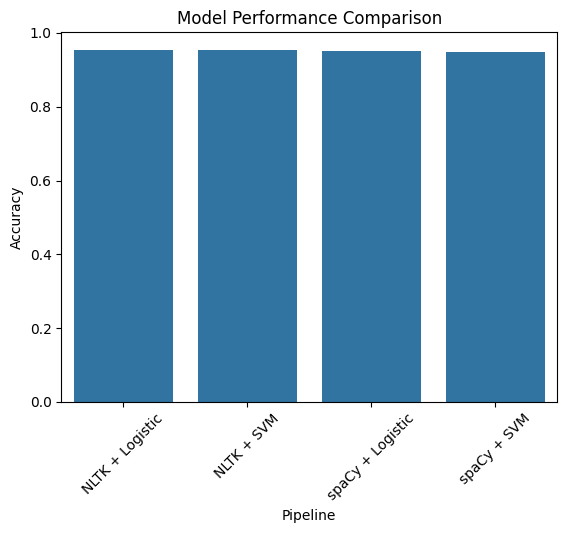

In [32]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.barplot(x="Pipeline", y="Accuracy", data=results)

plt.xticks(rotation=45)

plt.title("Model Performance Comparison")

plt.show()


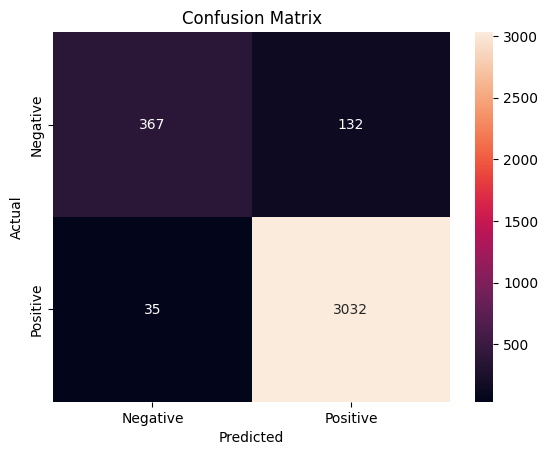

In [33]:
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred_log_nltk)

sns.heatmap(cm, annot=True, fmt="d",
            xticklabels=["Negative","Positive"],
            yticklabels=["Negative","Positive"])

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()


From the confusion matrix we can conclude that the model has positive bias.

# BERT(Bidirectional Encoder Representations from Transformers)

* Change the labels as it cannot process strings.

In [34]:
label_map = {
    "negative":0,
    "positive":1
}

y_train_bert = y_train.map(label_map)
y_test_bert = y_test.map(label_map)


BERT needs the input to be of the same length,if the sentence is too short we add padding if it is too long we chop it at 256 tokens.

In [35]:
from transformers import BertTokenizer

tokenizer = BertTokenizer.from_pretrained("bert-base-uncased")


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

In [36]:
train_encodings = tokenizer(
    X_train.tolist(),
    truncation=True,
    padding=True,
    max_length=256
)

test_encodings = tokenizer(
    X_test.tolist(),
    truncation=True,
    padding=True,
    max_length=256
)


BERT needs the input as dictionary format{input_id,attention_mask}.

In [37]:
import torch

class YelpDataset(torch.utils.data.Dataset):

    def __init__(self, encodings, labels):
        self.encodings = encodings
        self.labels = labels

    def __getitem__(self, idx):
        item = {key: torch.tensor(val[idx]) for key, val in self.encodings.items()}
        item["labels"] = torch.tensor(self.labels.iloc[idx])
        return item

    def __len__(self):
        return len(self.labels)


In [38]:
train_dataset = YelpDataset(train_encodings, y_train_bert)
test_dataset = YelpDataset(test_encodings, y_test_bert)


Since we have an imbalanced class we try to compute class weights->tell BERT to pay more attention to the smaller classes.

In [39]:
from sklearn.utils.class_weight import compute_class_weight
import numpy as np

classes = np.unique(y_train_bert)

weights = compute_class_weight(
    class_weight="balanced",
    classes=classes,
    y=y_train_bert
)

class_weights = torch.tensor(weights, dtype=torch.float)


Adding a new classification head on the top to the pre-trained BERT.

BERT outputs "logits" (raw scores). argmax picks the highest score to decide if the final answer is 0 or 1.

In [40]:
from transformers import BertForSequenceClassification

model = BertForSequenceClassification.from_pretrained(
    "bert-base-uncased",
    num_labels=2
)
model.to("cuda")

from transformers import TrainingArguments

training_args = TrainingArguments(
    output_dir="./results",
    num_train_epochs=3,
    per_device_train_batch_size=8,
    per_device_eval_batch_size=8,
    eval_strategy="epoch", # Changed from evaluation_strategy to eval_strategy
    logging_dir="./logs",
    save_strategy="epoch"
)

config.json:   0%|          | 0.00/570 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/440M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: bert-base-uncased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
classifier.bias                            | MISSING    | 
classifier.weight                          | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.
`logging_dir` is deprecated and will 

In [53]:
from transformers import Trainer
from sklearn.metrics import accuracy_score, precision_recall_fscore_support
import numpy as np
def compute_metrics(pred):

    labels = pred.label_ids
    preds = np.argmax(pred.predictions, axis=1)

    precision, recall, f1, _ = precision_recall_fscore_support(
        labels,
        preds,
        average="binary"
    )

    acc = accuracy_score(labels, preds)

    return {
        "accuracy":acc,
        "f1":f1,
        "precision":precision,
        "recall":recall
    }


In [56]:
trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=test_dataset,
    compute_metrics=compute_metrics
)
trainer.train()


Epoch,Training Loss,Validation Loss,Accuracy,F1,Precision,Recall
1,0.047214,0.731613,0.903904,0.894967,0.985542,0.819639
2,0.020420,0.277674,0.956957,0.956256,0.971074,0.941884
3,0.003456,0.310238,0.960961,0.960326,0.975207,0.945892


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

TrainOutput(global_step=1500, training_loss=0.023696677684783937, metrics={'train_runtime': 864.345, 'train_samples_per_second': 13.866, 'train_steps_per_second': 1.735, 'total_flos': 1576692999244800.0, 'train_loss': 0.023696677684783937, 'epoch': 3.0})

In [57]:
trainer.evaluate()


{'eval_loss': 0.3102380335330963,
 'eval_accuracy': 0.960960960960961,
 'eval_f1': 0.960325534079349,
 'eval_precision': 0.9752066115702479,
 'eval_recall': 0.9458917835671342,
 'eval_runtime': 16.9743,
 'eval_samples_per_second': 58.854,
 'eval_steps_per_second': 7.364,
 'epoch': 3.0}

* The BERT model surpassed the previous classical models (NLTK/SVM) with an Accuracy of 96.1% and a very high F1-score of 0.96.
* Overall accuracy went up, your Precision (97.5%) is now higher than your Recall (94.5%).
* This happens because BERT understands the semantic relationship between words. It isn't just looking for keywords like "management"; it’s looking for the context of management.


In [73]:
from transformers import DistilBertTokenizer

tokenizer = DistilBertTokenizer.from_pretrained("distilbert-base-uncased")


tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

In [74]:
train_encodings = tokenizer(
    X_train.tolist(),
    truncation=True,
    padding=True,
    max_length=256
)

test_encodings = tokenizer(
    X_test.tolist(),
    truncation=True,
    padding=True,
    max_length=256
)


In [75]:
import torch

class YelpDataset(torch.utils.data.Dataset):

    def __init__(self, encodings, labels):
        self.encodings = encodings
        self.labels = labels

    def __getitem__(self, idx):

        item = {k: torch.tensor(v[idx]) for k,v in self.encodings.items()}

        item["labels"] = torch.tensor(self.labels.iloc[idx])

        return item

    def __len__(self):
        return len(self.labels)


In [83]:
train_dataset = YelpDataset(train_encodings, y_train_bert)
test_dataset = YelpDataset(test_encodings, y_test_bert)

In [84]:
from transformers import DistilBertForSequenceClassification

model = DistilBertForSequenceClassification.from_pretrained(
    "distilbert-base-uncased",
    num_labels=2
)


Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
pre_classifier.weight   | MISSING    | 
classifier.bias         | MISSING    | 
classifier.weight       | MISSING    | 
pre_classifier.bias     | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


In [85]:
from transformers import TrainingArguments

training_args = TrainingArguments(
    output_dir="./results1",
    learning_rate=2e-5,
    num_train_epochs=4,
    per_device_train_batch_size=16,
    per_device_eval_batch_size=16,
    eval_strategy="epoch",
    save_strategy="epoch"
)

In [86]:
trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=test_dataset,
    compute_metrics=compute_metrics
)
trainer.train()
trainer.evaluate()

Epoch,Training Loss,Validation Loss,Accuracy,F1,Precision,Recall
1,No log,0.139940,0.951952,0.951020,0.968815,0.933868
2,0.176951,0.157534,0.951952,0.951020,0.968815,0.933868
3,0.176951,0.203336,0.949950,0.949900,0.949900,0.949900
4,0.027164,0.226716,0.948949,0.948223,0.960905,0.935872


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

{'eval_loss': 0.2267163097858429,
 'eval_accuracy': 0.948948948948949,
 'eval_f1': 0.9482233502538071,
 'eval_precision': 0.9609053497942387,
 'eval_recall': 0.935871743486974,
 'eval_runtime': 7.5612,
 'eval_samples_per_second': 132.122,
 'eval_steps_per_second': 8.332,
 'epoch': 4.0}

Why the accuracy reduced:

* Fewer Layers: DistilBERT has 6 layers instead of BERT’s 12. It has less "memory" to store the nuances of your text data.

* Information Loss: During distillation, some of the fine-grained "attention" (the way BERT links words together) is lost. This usually results in a 1-3% performance drop, which is exactly what you are seeing.

The Precision (96.1%) is still higher than the Recall (93.5%). This confirms that Transformer models (even small ones) are very cautious.